#### Sử dụng mô hình Text-to-Text Transfer Transformer

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

base_path = "/content/drive/MyDrive/Deep_Learning_Email/dataset_split/"


train_df = pd.read_csv(base_path + "train.csv")
val_df   = pd.read_csv(base_path + "val.csv")
test_df  = pd.read_csv(base_path + "test.csv")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import torch
import gc
from datasets import Dataset
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from transformers import Seq2SeqTrainingArguments

SETUP VÀ TẢI DỮ LIỆU

In [3]:
# Chuyển pandas dataframe sang dạng Dataset của HuggingFace để xử lý cho nhanh
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Khởi tạo Tokenizer của T5-base
model_name = "t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)

# Hàm chuyển đổi văn bản thành Input IDs (Tokenization)
def preprocess_function(examples):
    # Prefix "reply email:" giúp T5 biết nó đang làm nhiệm vụ gì
    inputs = ["reply email: " + doc for doc in examples["Input_Text"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")

    # Xử lý nhãn (Output_Text)
    labels = tokenizer(examples["Output_Text"], max_length=256, truncation=True, padding="max_length")
    # Thay thế id của pad token bằng -100 để mô hình bỏ qua khi tính Loss
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Đang mã hóa Token (Tokenization)...")
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess_function, batched=True, remove_columns=val_dataset.column_names)
tokenized_test = test_dataset.map(preprocess_function, batched=True, remove_columns=test_dataset.column_names)

# Công cụ tự động gộp batch dữ liệu
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)

# Công cụ tự động gộp batch dữ liệu
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Đang mã hóa Token (Tokenization)...


Map:   0%|          | 0/11069 [00:00<?, ? examples/s]

Map:   0%|          | 0/1384 [00:00<?, ? examples/s]

Map:   0%|          | 0/1384 [00:00<?, ? examples/s]

In [8]:
!rm -rf ./t5-email-reply-model

#### TRAIN MÔ HÌNH

In [9]:
from transformers import T5ForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer

# Tải mô hình đã pre-train
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Cấu hình các tham số huấn luyện (Đã sửa lỗi phiên bản mới)
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5-email-reply-model",
    eval_strategy="epoch",            # Dùng eval_strategy thay cho evaluation_strategy
    save_strategy="epoch",            # Nên thêm dòng này để mô hình lưu checkpoint đồng bộ với lúc đánh giá
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    max_grad_norm=1.0,                # Chống bùng nổ đạo hàm
    save_total_limit=2,
    num_train_epochs=10,
    predict_with_generate=True,
    bf16=True
)

# 3. Khởi tạo Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

# 4. Bắt đầu quá trình huấn luyện
print("Bắt đầu train mô hình...")
trainer.train()

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Bắt đầu train mô hình...


Epoch,Training Loss,Validation Loss
1,3.562173,3.317322
2,3.451778,3.250982
3,3.342901,3.219591
4,3.363091,3.200291
5,3.280544,3.186061
6,3.270518,3.179951
7,3.214453,3.169327
8,3.184474,3.167548
9,3.145435,3.166944
10,3.120893,3.166596


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=27680, training_loss=3.311850884057194, metrics={'train_runtime': 4172.3055, 'train_samples_per_second': 26.53, 'train_steps_per_second': 6.634, 'total_flos': 6.74055489060864e+16, 'train_loss': 3.311850884057194, 'epoch': 10.0})

#### Đánh giá mô hình

In [19]:
import evaluate
import numpy as np
import math
from transformers.trainer_callback import ProgressCallback

# 1. Tải các công cụ đánh giá
print("Đang tải các bộ đánh giá (BERTScore có thể mất chút thời gian để tải model chấm điểm)...")
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
bertscore_metric = evaluate.load("bertscore")

# 2. Định nghĩa hàm tính toán các chỉ số
def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    rouge_result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    bleu_result = bleu_metric.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])
    bertscore_result = bertscore_metric.compute(predictions=decoded_preds, references=decoded_labels, lang="en")

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "bleu": bleu_result["score"],
        "bertscore_f1": np.mean(bertscore_result["f1"]),
        "bertscore_precision": np.mean(bertscore_result["precision"]),
        "bertscore_recall": np.mean(bertscore_result["recall"]),
    }

# 3. Gắn hàm đánh giá vào Trainer
trainer.compute_metrics = compute_metrics

# --- 4. KHÔI PHỤC THANH TIẾN TRÌNH ĐÁNH GIÁ ---
# Xóa callback gây lỗi
callbacks_to_remove = [cb for cb in trainer.callback_handler.callbacks if "Notebook" in type(cb).__name__]
for cb in callbacks_to_remove:
    trainer.remove_callback(cb)

# Thêm lại callback chuẩn (hiển thị thanh đồ họa trong Colab)
if not any(isinstance(cb, ProgressCallback) for cb in trainer.callback_handler.callbacks):
    trainer.add_callback(ProgressCallback)
# ----------------------------------------------

# 5. Bắt đầu đánh giá
print("Bắt đầu đánh giá trên tập Test_dataset. Quá trình này có thể tốn vài phút...")
eval_results = trainer.evaluate(eval_dataset=tokenized_test)

# 6. Tính Perplexity
eval_loss = eval_results.get("eval_loss")
perplexity = math.exp(eval_loss) if eval_loss is not None else float("inf")

# 7. IN KẾT QUẢ
print("\n" + "="*70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (TEST SET)")
print("="*70)
print(f"Test Loss:      {eval_loss:.4f}")
print(f"Perplexity:     {perplexity:.4f}")
print("-" * 70)
print(f"ROUGE-1:        {eval_results.get('eval_rouge1', 0):.4f}")
print(f"ROUGE-2:        {eval_results.get('eval_rouge2', 0):.4f}")
print(f"ROUGE-L:        {eval_results.get('eval_rougeL', 0):.4f}")
print("-" * 70)
print(f"BLEU Score:     {eval_results.get('eval_bleu', 0):.4f}")
print("-" * 70)
print(f"BERTScore F1:   {eval_results.get('eval_bertscore_f1', 0):.4f}")
print(f"BERTScore Prec: {eval_results.get('eval_bertscore_precision', 0):.4f}")
print(f"BERTScore Rec:  {eval_results.get('eval_bertscore_recall', 0):.4f}")
print("="*70)

Đang tải các bộ đánh giá (BERTScore có thể mất chút thời gian để tải model chấm điểm)...
Bắt đầu đánh giá trên tập Test_dataset. Quá trình này có thể tốn vài phút...


  0%|          | 0/346 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (TEST SET)
Test Loss:      3.2634
Perplexity:     26.1378
----------------------------------------------------------------------
ROUGE-1:        0.1364
ROUGE-2:        0.0254
ROUGE-L:        0.1149
----------------------------------------------------------------------
BLEU Score:     0.4502
----------------------------------------------------------------------
BERTScore F1:   0.8408
BERTScore Prec: 0.8529
BERTScore Rec:  0.8297


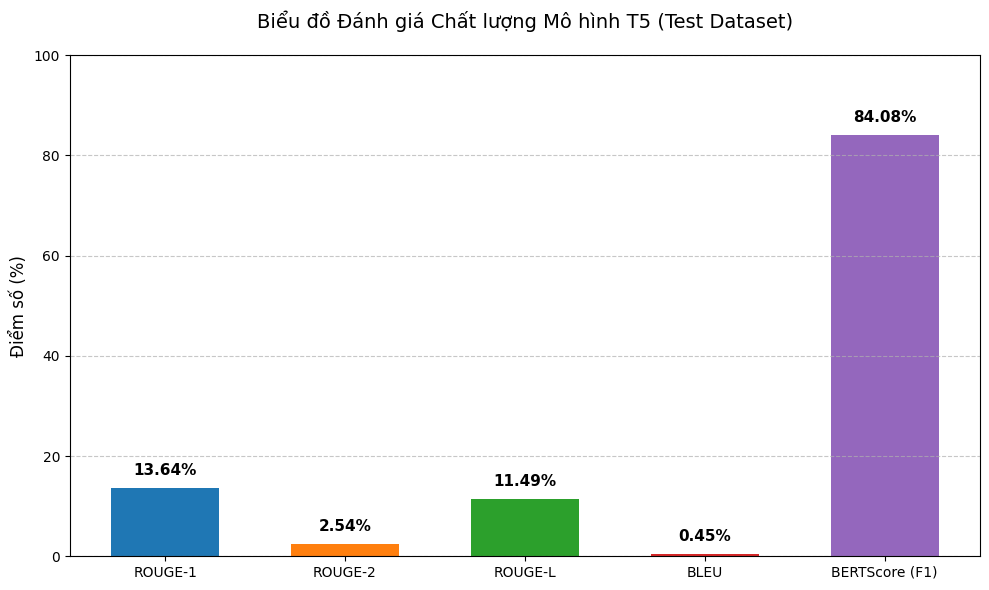

Test Loss: 3.2634 | Perplexity: 26.1378


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Chuyển đổi các điểm số về cùng thang điểm 100 (%) để dễ so sánh
# Lưu ý: Thư viện sacrebleu mặc định đã tính ở thang 100, còn rouge và bertscore ở thang 0-1
metrics_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'BERTScore (F1)']
scores = [
    eval_results.get('eval_rouge1', 0) * 100,
    eval_results.get('eval_rouge2', 0) * 100,
    eval_results.get('eval_rougeL', 0) * 100,
    eval_results.get('eval_bleu', 0),
    eval_results.get('eval_bertscore_f1', 0) * 100
]

# Cấu hình kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(metrics_names, scores, color=colors, width=0.6)

# Tùy chỉnh tiêu đề và nhãn
plt.title('Biểu đồ Đánh giá Chất lượng Mô hình T5 (Test Dataset)', fontsize=14, pad=20)
plt.ylabel('Điểm số (%)', fontsize=12)
plt.ylim(0, 100) # Thiết lập trục Y từ 0 đến 100%

# Hiển thị giá trị cụ thể trên từng cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Thêm lưới nền cho dễ nhìn
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Lưu ảnh và hiển thị
plt.tight_layout()
plt.savefig('evaluation_metrics_chart.png', dpi=300)
plt.show()

print(f"Test Loss: {eval_loss:.4f} | Perplexity: {perplexity:.4f}")

#### Lưu Mô Hình

In [21]:
# Đặt tên thư mục bạn muốn lưu (có thể tùy chỉnh)
save_path = "./my_saved_model_v1"

# Lưu mô hình (thông qua trainer)
trainer.save_model(save_path)

# Lưu lại tokenizer để dùng kèm
tokenizer.save_pretrained(save_path)

print(f"Đã lưu thành công mô hình và tokenizer tại: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu thành công mô hình và tokenizer tại: ./my_saved_model_v1


In [22]:
import shutil
from google.colab import files

# 1. Nén thư mục mô hình thành file .zip
# Tên file nén sẽ là my_model.zip
shutil.make_archive('my_model', 'zip', 'my_saved_model_v1')

# 2. Tải file .zip đó về máy tính
files.download('my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>